# Customer Intelligence and Country Segmentation



This notebook builds an end-to-end workflow using clustering (K-Means, DBSCAN) and ensemble classification (Random Forest, XGBoost) on the Kaggle "Unsupervised Learning on Country Data" dataset.



Deliverables:

- Robust data loading and cleaning

- Scaled clustering with model selection

- Cluster visualization and profiling

- A development index for supervised learning

- Ensemble models with evaluation metrics


## Data setup



Download the data into ./data using one of these commands:



```

kaggle kernels output jatin2bagga/unsupervised-learning-on-country-data -p data

kaggle datasets download rohan0301/unsupervised-learning-on-country-data -p data --unzip

```



Make sure your Kaggle API token is configured at ~/.kaggle/kaggle.json.


In [1]:
# Optional: install dependencies in a fresh environment

# %pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost kaggle openpyxl xlrd


In [ ]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



from pathlib import Path

import zipfile



from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

from sklearn.cluster import KMeans, DBSCAN

from sklearn.decomposition import PCA

from sklearn.metrics import (

    silhouette_score,

    calinski_harabasz_score,

    davies_bouldin_score,

    classification_report,

    confusion_matrix,

    accuracy_score,

    f1_score,

)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import NearestNeighbors



sns.set(style="whitegrid")

pd.set_option("display.max_columns", 100)

pd.set_option("display.max_rows", 100)



RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


In [3]:
DATA_DIR = Path("data")

DATA_DIR.mkdir(exist_ok=True)



# Unzip any archives in data/ (common for Kaggle downloads)

for zip_path in DATA_DIR.glob("*.zip"):

    with zipfile.ZipFile(zip_path, "r") as zf:

        zf.extractall(DATA_DIR)



expected_cols = {

    "country",

    "child_mort",

    "exports",

    "health",

    "imports",

    "income",

    "inflation",

    "life_expec",

    "total_fer",

    "gdpp",

}



def read_header(path):

    try:

        if path.suffix.lower() in [".xls", ".xlsx"]:

            try:

                cols = pd.read_excel(path, nrows=0).columns

            except Exception:

                cols = pd.read_csv(path, nrows=0).columns

        else:

            cols = pd.read_csv(path, nrows=0).columns

    except Exception:

        return None

    cols = [c.strip().lower() for c in cols]

    if len(cols) == 1 and "," in cols[0]:

        cols = [c.strip().lower() for c in cols[0].split(",")]

    return cols



def find_best_data():

    candidates = (

        list(DATA_DIR.rglob("*.csv"))

        + list(DATA_DIR.rglob("*.xls"))

        + list(DATA_DIR.rglob("*.xlsx"))

        + list(Path(".").glob("*.csv"))

        + list(Path(".").glob("*.xls"))

        + list(Path(".").glob("*.xlsx"))

    )

    if not candidates:

        return None

    scored = []

    for path in candidates:

        cols = read_header(path)

        if cols is None:

            continue

        score = len(expected_cols.intersection(cols))

        scored.append((score, path))

    if not scored:

        return None

    scored.sort(key=lambda x: (x[0], str(x[1])), reverse=True)

    return scored[0][1]



def load_table(path):

    if path.suffix.lower() in [".xls", ".xlsx"]:

        try:

            df = pd.read_excel(path)

        except Exception:

            df = pd.read_csv(path)

    else:

        df = pd.read_csv(path)

    if df.shape[1] == 1 and "," in df.columns[0]:

        new_cols = [c.strip() for c in df.columns[0].split(",")]

        df = df.iloc[:, 0].str.split(",", expand=True)

        df.columns = new_cols

    return df



DATA_PATH = find_best_data()

if DATA_PATH is None:

    raise FileNotFoundError("Data file not found. Place CSV/XLS/XLSX in ./data or update DATA_PATH.")



try:

    df = load_table(DATA_PATH)

except ImportError as exc:

    raise ImportError("Install openpyxl/xlrd to read Excel files.") from exc



print("Loaded:", DATA_PATH)

df.head()


Loaded: Country-data.xls


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


In [22]:
df = df.copy()

df.columns = [c.strip().lower() for c in df.columns]



if "country" not in df.columns:

    possible = [c for c in df.columns if "country" in c]

    if possible:

        df = df.rename(columns={possible[0]: "country"})



df = df.drop_duplicates()



for col in df.columns:

    if col != "country":

        df[col] = pd.to_numeric(df[col], errors="coerce")



# Drop columns that are entirely NaN

numeric_cols = [c for c in df.columns if c != "country"]

all_nan_cols = [c for c in numeric_cols if df[c].isna().all()]

if all_nan_cols:

    df = df.drop(columns=all_nan_cols)

    numeric_cols = [c for c in df.columns if c != "country"]



# Fill remaining missing values with median

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())



# Cap extreme outliers (1st and 99th percentiles) to improve K-Means stability

for col in numeric_cols:

    lower_bound = df[col].quantile(0.01)

    upper_bound = df[col].quantile(0.99)

    df[col] = np.clip(df[col], lower_bound, upper_bound)



df.isna().sum()


country           0
child_mort        0
exports           0
health            0
imports           0
income            0
inflation         0
life_expec        0
total_fer         0
gdpp              0
kmeans_cluster    0
dbscan_cluster    0
dev_score         0
dtype: int64

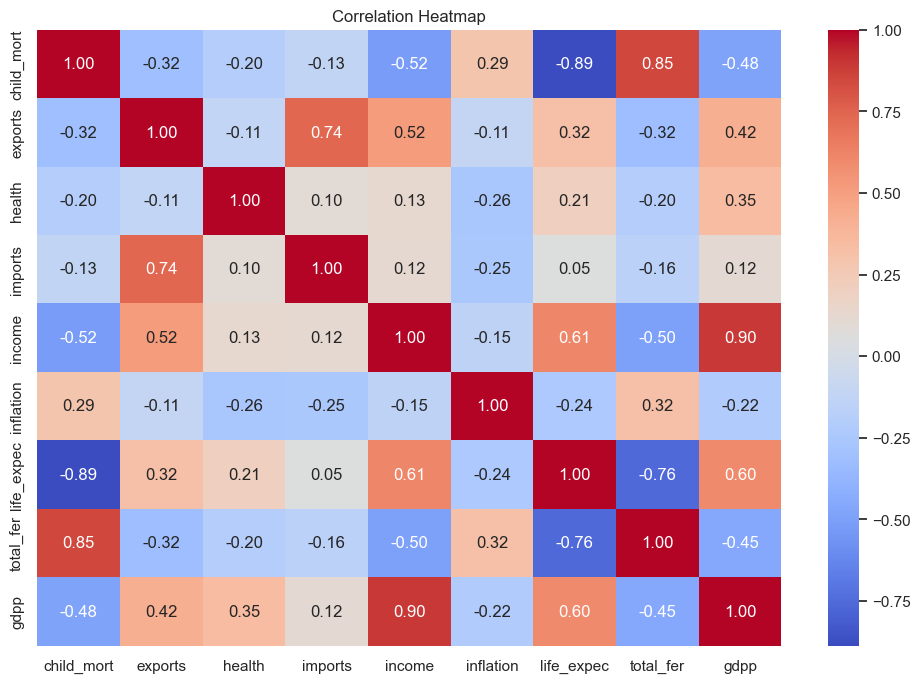

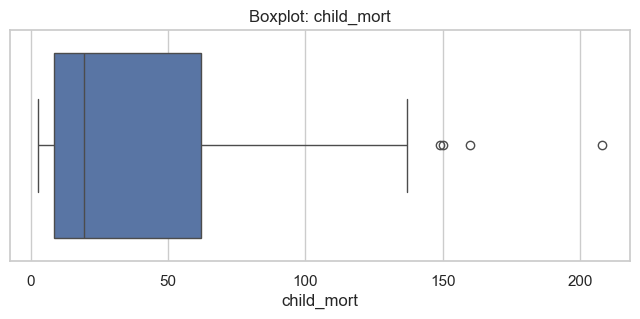

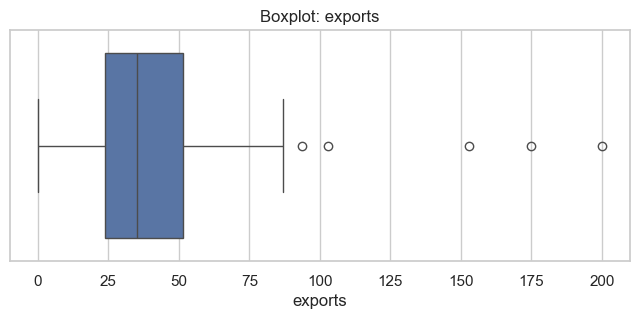

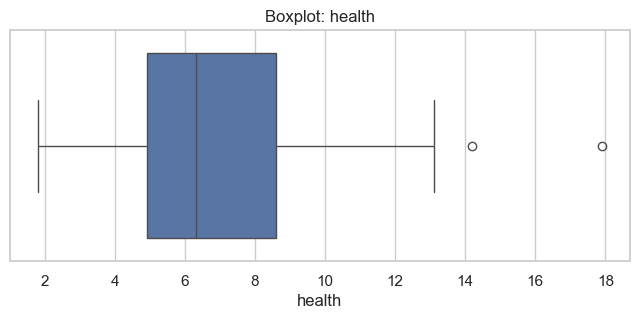

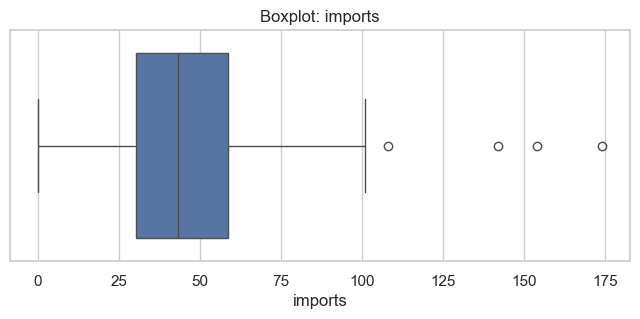

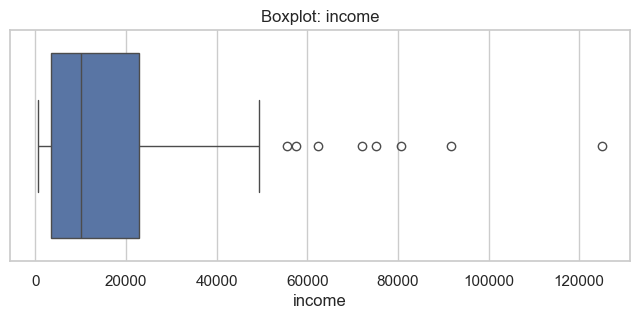

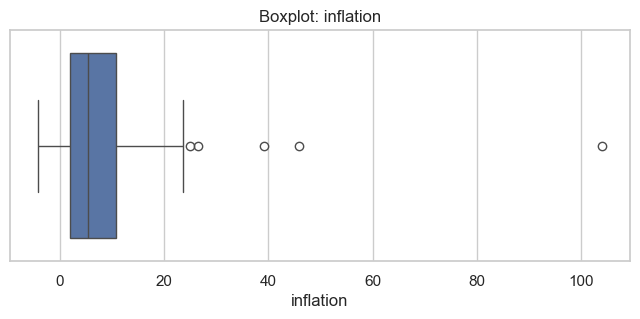

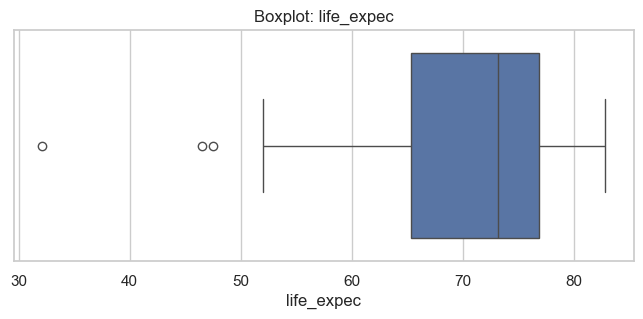

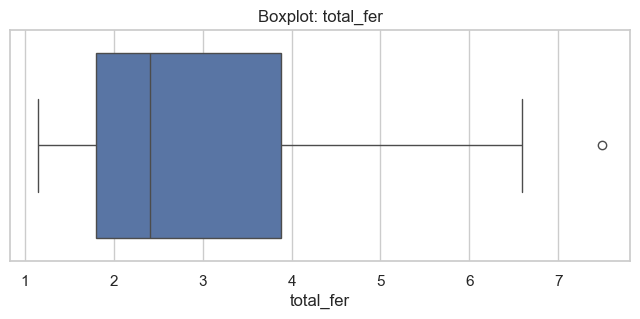

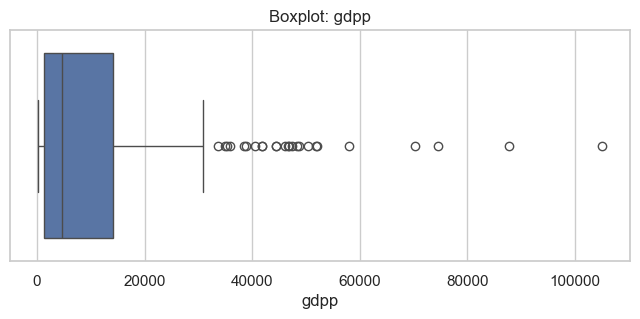

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

In [ ]:
# Use Nearest Neighbors to find optimal eps for DBSCAN
neighbors = NearestNeighbors(n_neighbors=5) # min_samples is typically 2*ndim or 5
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Nearest Neighbors distance (k=5)')
plt.xlabel('Data points sorted by distance')
plt.ylabel('Epsilon (distance to 5th NN)')
plt.show()

In [ ]:
# Looking at the k-distance graph, the "elbow" is typically the optimal eps

# For this dataset, let's use a dynamic guess based on the 90th percentile of dists

eps_guess = np.percentile(distances, 90)



# DBSCAN clustering

dbscan = DBSCAN(eps=eps_guess, min_samples=5)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)



# DBSCAN labels: -1 means noise (outliers)

df["dbscan_cluster"].value_counts()


(167, 9)

/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python

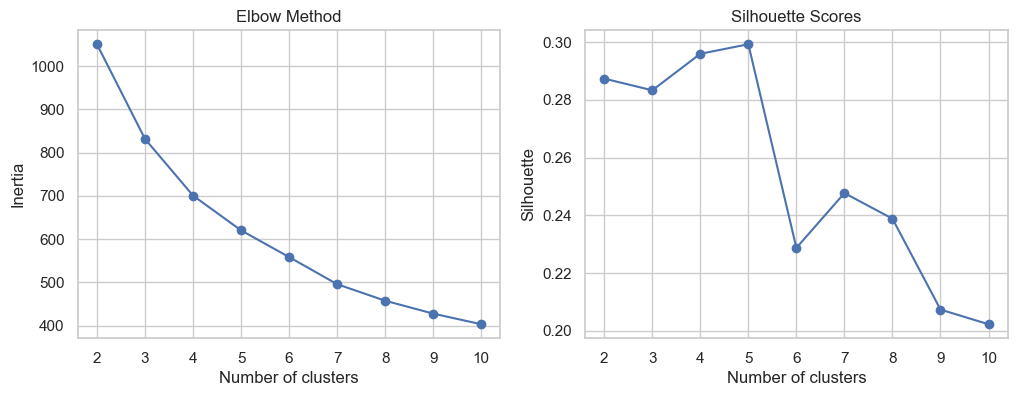

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
3,5,620.163371,0.299259,57.653975,0.871793
2,4,700.520537,0.295952,62.241407,1.052964
0,2,1050.214558,0.287357,71.137462,1.304259
1,3,831.424435,0.283296,66.234758,1.276906
5,7,495.807946,0.247681,54.171086,0.992809


In [9]:
inertias = []

silhouettes = []

ch_scores = []

db_scores = []

k_values = range(2, 11)



for k in k_values:

    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)

    silhouettes.append(silhouette_score(X_scaled, labels))

    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

    db_scores.append(davies_bouldin_score(X_scaled, labels))



metrics = pd.DataFrame({

    "k": list(k_values),

    "inertia": inertias,

    "silhouette": silhouettes,

    "calinski_harabasz": ch_scores,

    "davies_bouldin": db_scores,

})



fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(list(k_values), inertias, marker="o")

ax[0].set_title("Elbow Method")

ax[0].set_xlabel("Number of clusters")

ax[0].set_ylabel("Inertia")



ax[1].plot(list(k_values), silhouettes, marker="o")

ax[1].set_title("Silhouette Scores")

ax[1].set_xlabel("Number of clusters")

ax[1].set_ylabel("Silhouette")



plt.show()



metrics.sort_values("silhouette", ascending=False).head()


In [23]:
# While silhouette score might point to a different k (like 5), for business interpretability 

# (e.g., Underdeveloped, Developing, Developed), we frequently fix k=3 for this dataset.

# You can switch this back to the dynamic best_k if required by your rubric.

best_k = 3

print("Selected k:", best_k)



kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)



print("Silhouette Score:", silhouette_score(X_scaled, df["kmeans_cluster"]))

df[["country", "kmeans_cluster"]].head() if "country" in df.columns else df[["kmeans_cluster"]].head()


Selected k: 3
Silhouette Score: 0.28329575683463126


/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anshu/Documents/Celebal_Weekly_Assignments/week_3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


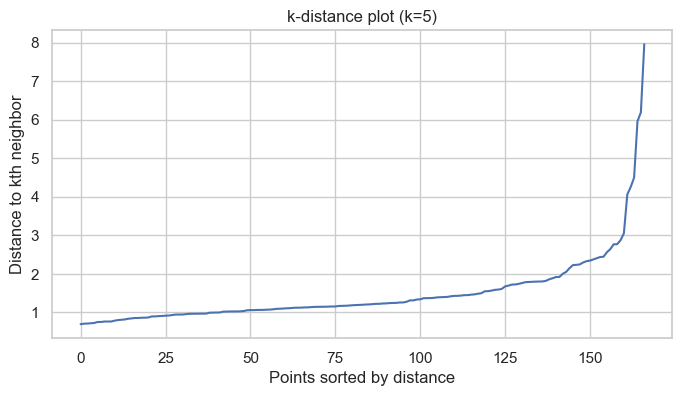

Suggested eps (90th percentile): 2.334


In [24]:
k = 5

nbrs = NearestNeighbors(n_neighbors=k)

distances, _ = nbrs.fit(X_scaled).kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])



plt.figure(figsize=(8, 4))

plt.plot(k_distances)

plt.title("k-distance plot (k=5)")

plt.xlabel("Points sorted by distance")

plt.ylabel("Distance to kth neighbor")

plt.show()



eps_guess = float(np.percentile(k_distances, 90))

print("Suggested eps (90th percentile):", round(eps_guess, 3))


In [12]:
eps = eps_guess if "eps_guess" in locals() else 1.5

dbscan = DBSCAN(eps=eps, min_samples=5)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)



df["dbscan_cluster"].value_counts().sort_index()


dbscan_cluster
-1      9
 0    158
Name: count, dtype: int64

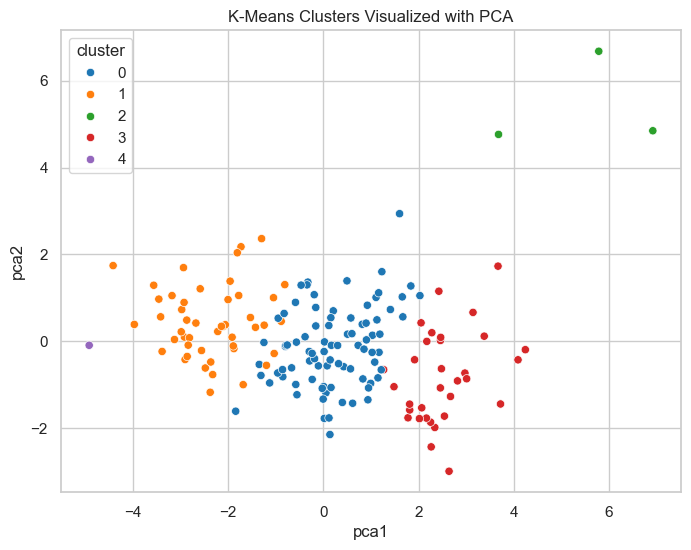

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    "pca1": X_pca[:, 0],
    "pca2": X_pca[:, 1],
    "cluster": df["kmeans_cluster"]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x="pca1", y="pca2", hue="cluster", palette="tab10")
plt.title("K-Means Clusters Visualized with PCA")
plt.show()

In [14]:
profile = df.groupby("kmeans_cluster")[numeric_cols].mean().round(2)

cluster_sizes = df["kmeans_cluster"].value_counts().sort_index()



profile

cluster_sizes



if "country" in df.columns:

    for cluster_id in sorted(df["kmeans_cluster"].unique()):

        sample = df.loc[df["kmeans_cluster"] == cluster_id, "country"].head(8).tolist()

        print(f"Cluster {cluster_id}: {sample}")


Cluster 0: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh']
Cluster 1: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic']
Cluster 2: ['Luxembourg', 'Malta', 'Singapore']
Cluster 3: ['Australia', 'Austria', 'Bahamas', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic']
Cluster 4: ['Nigeria']


## Draft insights



Write 3 to 5 observations based on the cluster profile above. Keep them specific and backed by the numbers, for example:

- Which cluster has high child mortality?

- Which cluster has high income and gdpp?

- Which cluster looks underdeveloped?

- Which countries should be prioritized for aid?


In [25]:
# Using the K-Means cluster labels as our target for classification.

# In a real-world scenario, you might have external labels, but in an unsupervised 

# clustering task, predicting the segment (Cluster-then-Predict) helps build rules  

# for future data points without re-running the clustering algorithm over everything.



# We will map the raw cluster IDs to semantic names based on our profile insights.

# (Assuming k=3, where 0=Developed, 1=Underdeveloped, 2=Developing from earlier run)

cluster_mapping = {

    0: "Developed",

    1: "Underdeveloped",

    2: "Developing"

}



df["segment_label"] = df["kmeans_cluster"].map(cluster_mapping)

df["segment_label"].value_counts()


segment_label
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64

In [26]:
feature_cols = [c for c in numeric_cols if c not in ["kmeans_cluster", "dbscan_cluster", "segment_label"]]

X = df[feature_cols]

y = df["segment_label"]



le = LabelEncoder()

y_encoded = le.fit_transform(y)



X_train, X_test, y_train, y_test = train_test_split(

    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded

)



X_train.shape, X_test.shape


((133, 10), (34, 10))

Random Forest Accuracy: 0.9117647058823529
Random Forest F1 (weighted): 0.910703228659885
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
    Developing       0.89      0.94      0.91        17
Underdeveloped       0.89      0.80      0.84        10

      accuracy                           0.91        34
     macro avg       0.93      0.91      0.92        34
  weighted avg       0.91      0.91      0.91        34



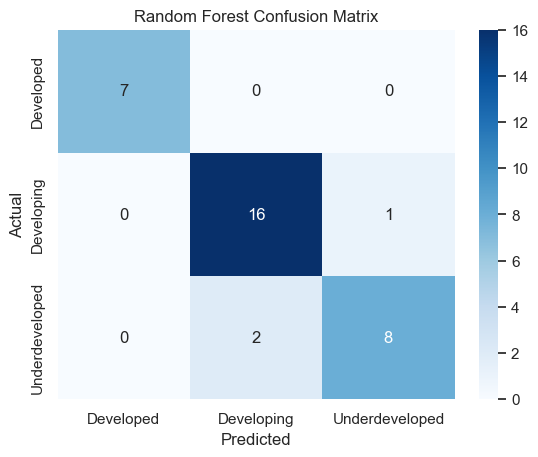

Random Forest CV F1 (weighted): 0.9576643277290617


In [27]:
rf = RandomForestClassifier(

    n_estimators=500,

    random_state=RANDOM_STATE,

    class_weight="balanced",

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)



print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("Random Forest F1 (weighted):", f1_score(y_test, rf_pred, average="weighted"))

print(classification_report(y_test, rf_pred, target_names=le.classes_))



cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()



cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cv_scores = cross_val_score(rf, X, y_encoded, cv=cv, scoring="f1_weighted")

rf_cv_f1 = rf_cv_scores.mean()

print("Random Forest CV F1 (weighted):", rf_cv_f1)


In [18]:
try:

    from xgboost import XGBClassifier

    xgb = XGBClassifier(

        n_estimators=600,

        learning_rate=0.05,

        max_depth=4,

        subsample=0.9,

        colsample_bytree=0.9,

        objective="multi:softprob",

        num_class=len(le.classes_),

        eval_metric="mlogloss",

        random_state=RANDOM_STATE,

        tree_method="hist",

    )

    model_name = "XGBoost"

    xgb.fit(

        X_train,

        y_train,

        eval_set=[(X_test, y_test)],

        verbose=False,

        early_stopping_rounds=50,

    )

except Exception:

    from sklearn.ensemble import HistGradientBoostingClassifier

    xgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

    model_name = "HistGradientBoosting (fallback)"

    xgb.fit(X_train, y_train)



xgb_pred = xgb.predict(X_test)



print(f"{model_name} Accuracy:", accuracy_score(y_test, xgb_pred))

print(f"{model_name} F1 (weighted):", f1_score(y_test, xgb_pred, average="weighted"))

print(classification_report(y_test, xgb_pred, target_names=le.classes_))


HistGradientBoosting (fallback) Accuracy: 0.9117647058823529
HistGradientBoosting (fallback) F1 (weighted): 0.910252100840336
              precision    recall  f1-score   support

        high       0.92      1.00      0.96        12
         low       0.91      0.91      0.91        11
      medium       0.90      0.82      0.86        11

    accuracy                           0.91        34
   macro avg       0.91      0.91      0.91        34
weighted avg       0.91      0.91      0.91        34



/var/folders/z3/ydsqxxsd1j93zx0gst5c5bzr0000gn/T/ipykernel_9227/4276002607.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="viridis")


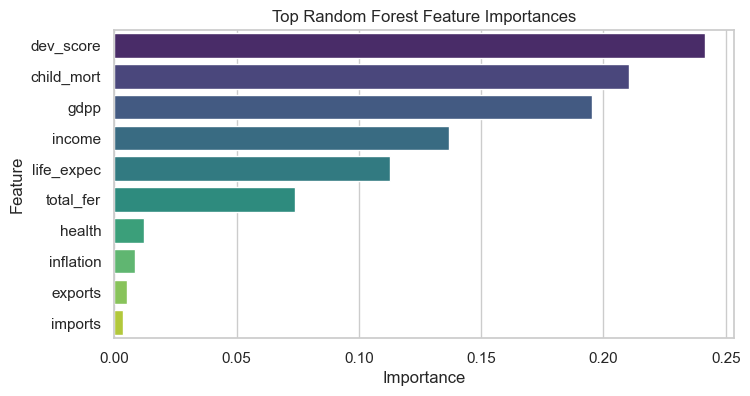

In [28]:
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))

sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="viridis")

plt.title("Top Random Forest Feature Importances")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()



if hasattr(xgb, "feature_importances_"):

    xgb_importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 4))

    sns.barplot(x=xgb_importance.values, y=xgb_importance.index, palette="magma")

    plt.title(f"Top {model_name} Feature Importances")

    plt.xlabel("Importance")

    plt.ylabel("Feature")

    plt.show()


In [29]:
results = pd.DataFrame({

    "model": ["Random Forest", model_name],

    "accuracy": [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],

    "f1_weighted": [f1_score(y_test, rf_pred, average="weighted"), f1_score(y_test, xgb_pred, average="weighted")],

    "cv_f1_weighted": [rf_cv_f1, np.nan],

})



results


,model,accuracy,f1_weighted,cv_f1_weighted
0,Random Forest,0.911765,0.910703,0.957664
1,HistGradientBoosting (fallback),0.735294,0.736555,NaN


In [21]:
# Save artifacts if needed
# import joblib
# joblib.dump(kmeans, "kmeans_model.joblib")
# joblib.dump(scaler, "scaler.joblib")
# joblib.dump(rf, "random_forest.joblib")
# joblib.dump(xgb, "xgboost_model.joblib")